In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="colorblind")
RESULTS_CSV = "results/results.csv"  # Update to full results path

df = pd.read_csv(RESULTS_CSV)
ok = df[df["status"] == "ok"].copy()
print(f"Total rows: {len(df)}, ok: {len(ok)}, non-ok: {len(df) - len(ok)}")

Total rows: 260, ok: 199, non-ok: 61


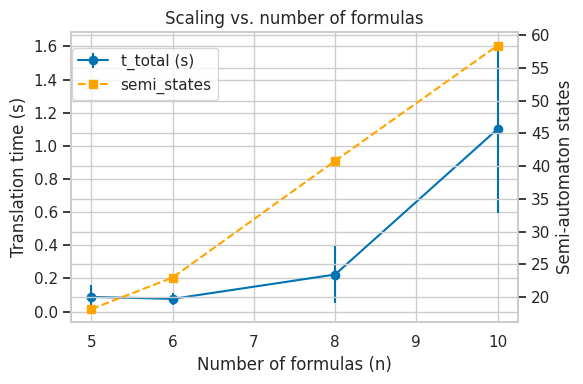

In [4]:
subset = ok[(ok["num_aps"] == 3) & (ok["formula_size"] == 5) & (ok["density"] == "medium")]
agg = subset.groupby("n").agg(
    t_mean=("t_total", "mean"), t_std=("t_total", "std"),
    states_mean=("semi_states", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.errorbar(agg["n"], agg["t_mean"], yerr=agg["t_std"], marker="o", label="t_total (s)")
ax1.set_xlabel("Number of formulas (n)")
ax1.set_ylabel("Translation time (s)")
ax2 = ax1.twinx()
ax2.plot(agg["n"], agg["states_mean"], marker="s", linestyle="--", color="orange", label="semi_states")
ax2.set_ylabel("Semi-automaton states")
ax1.set_title("Scaling vs. number of formulas")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.savefig("results/plot_scaling_n.pdf", bbox_inches="tight")
plt.show()

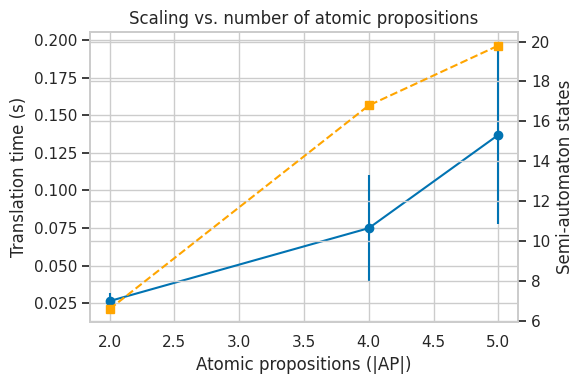

In [5]:
subset = ok[(ok["n"] == 4) & (ok["formula_size"] == 5) & (ok["density"] == "medium")]
agg = subset.groupby("num_aps").agg(
    t_mean=("t_total", "mean"), t_std=("t_total", "std"),
    states_mean=("semi_states", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.errorbar(agg["num_aps"], agg["t_mean"], yerr=agg["t_std"], marker="o")
ax1.set_xlabel("Atomic propositions (|AP|)")
ax1.set_ylabel("Translation time (s)")
ax2 = ax1.twinx()
ax2.plot(agg["num_aps"], agg["states_mean"], marker="s", linestyle="--", color="orange")
ax2.set_ylabel("Semi-automaton states")
ax1.set_title("Scaling vs. number of atomic propositions")
plt.tight_layout()
plt.savefig("results/plot_scaling_aps.pdf", bbox_inches="tight")
plt.show()

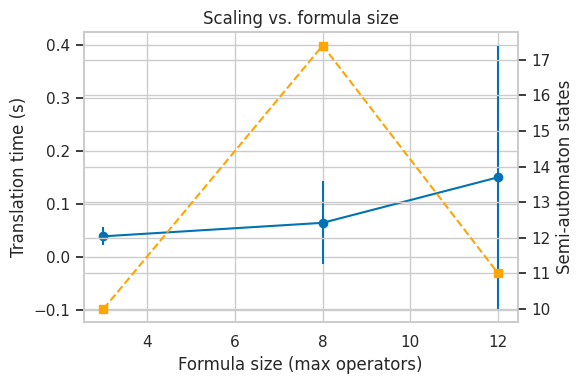

In [6]:
subset = ok[(ok["n"] == 4) & (ok["num_aps"] == 3) & (ok["density"] == "medium")]
agg = subset.groupby("formula_size").agg(
    t_mean=("t_total", "mean"), t_std=("t_total", "std"),
    states_mean=("semi_states", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.errorbar(agg["formula_size"], agg["t_mean"], yerr=agg["t_std"], marker="o")
ax1.set_xlabel("Formula size (max operators)")
ax1.set_ylabel("Translation time (s)")
ax2 = ax1.twinx()
ax2.plot(agg["formula_size"], agg["states_mean"], marker="s", linestyle="--", color="orange")
ax2.set_ylabel("Semi-automaton states")
ax1.set_title("Scaling vs. formula size")
plt.tight_layout()
plt.savefig("results/plot_scaling_fsize.pdf", bbox_inches="tight")
plt.show()

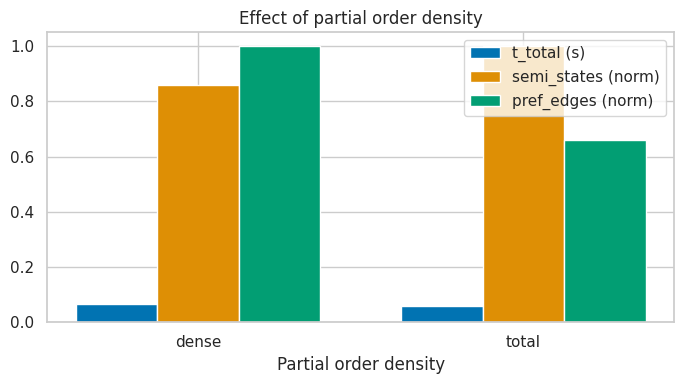

In [7]:
subset = ok[(ok["n"] == 4) & (ok["num_aps"] == 3) & (ok["formula_size"] == 5)]
agg = subset.groupby("density").agg(
    t_mean=("t_total", "mean"),
    states_mean=("semi_states", "mean"),
    pref_edges_mean=("pref_edges", "mean"),
).reset_index()

density_order = ["sparse", "medium", "dense", "total"]
agg["density"] = pd.Categorical(agg["density"], categories=density_order, ordered=True)
agg = agg.sort_values("density")

x = np.arange(len(agg))
width = 0.25
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width, agg["t_mean"], width, label="t_total (s)")
ax.bar(x, agg["states_mean"] / agg["states_mean"].max(), width, label="semi_states (norm)")
ax.bar(x + width, agg["pref_edges_mean"] / (agg["pref_edges_mean"].max() + 1e-9), width, label="pref_edges (norm)")
ax.set_xticks(x)
ax.set_xticklabels(agg["density"])
ax.set_xlabel("Partial order density")
ax.set_title("Effect of partial order density")
ax.legend()
plt.tight_layout()
plt.savefig("results/plot_density.pdf", bbox_inches="tight")
plt.show()

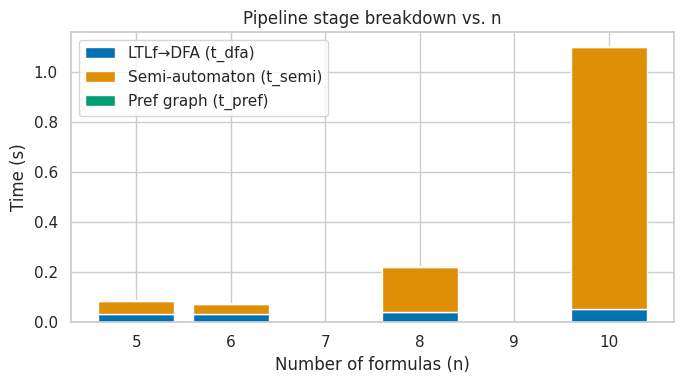

In [8]:
subset = ok[(ok["num_aps"] == 3) & (ok["formula_size"] == 5) & (ok["density"] == "medium")]
agg = subset.groupby("n").agg(
    t_dfa=("t_dfa", "mean"), t_semi=("t_semi", "mean"), t_pref=("t_pref", "mean")
).reset_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(agg["n"], agg["t_dfa"], label="LTLf\u2192DFA (t_dfa)")
ax.bar(agg["n"], agg["t_semi"], bottom=agg["t_dfa"], label="Semi-automaton (t_semi)")
ax.bar(agg["n"], agg["t_pref"], bottom=agg["t_dfa"] + agg["t_semi"], label="Pref graph (t_pref)")
ax.set_xlabel("Number of formulas (n)")
ax.set_ylabel("Time (s)")
ax.set_title("Pipeline stage breakdown vs. n")
ax.legend()
plt.tight_layout()
plt.savefig("results/plot_stage_breakdown.pdf", bbox_inches="tight")
plt.show()

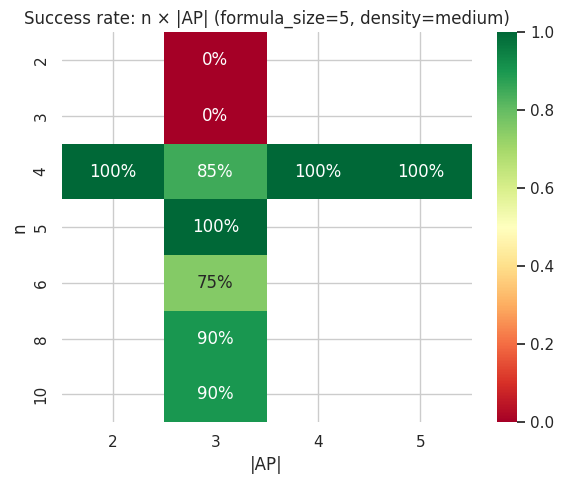

In [9]:
heat = df.groupby(["n", "num_aps"]).apply(
    lambda g: (g["status"] == "ok").mean()
).reset_index(name="success_rate")
pivot = heat.pivot(index="n", columns="num_aps", values="success_rate")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt=".0%", cmap="RdYlGn", vmin=0, vmax=1, ax=ax)
ax.set_title("Success rate: n \u00d7 |AP| (formula_size=5, density=medium)")
ax.set_xlabel("|AP|")
ax.set_ylabel("n")
plt.tight_layout()
plt.savefig("results/plot_heatmap.pdf", bbox_inches="tight")
plt.show()

In [10]:
summary = ok.groupby(["n", "num_aps", "formula_size", "density"]).agg(
    mean_t_total=("t_total", "mean"),
    mean_semi_states=("semi_states", "mean"),
    mean_pref_nodes=("pref_nodes", "mean"),
).round(3).reset_index()

total_per_combo = df.groupby(["n", "num_aps", "formula_size", "density"]).size().reset_index(name="total")
ok_per_combo = ok.groupby(["n", "num_aps", "formula_size", "density"]).size().reset_index(name="ok_count")
rate = total_per_combo.merge(ok_per_combo, how="left").fillna(0)
rate["success_pct"] = (rate["ok_count"] / rate["total"] * 100).round(1)

summary = summary.merge(rate[["n", "num_aps", "formula_size", "density", "success_pct"]], how="left")
print(summary.to_string(index=False))
summary.to_csv("results/summary_table.csv", index=False)

 n  num_aps  formula_size density  mean_t_total  mean_semi_states  mean_pref_nodes  success_pct
 4        2             5   dense         0.026             6.600            2.400        100.0
 4        2             5  medium         0.026             6.600            2.400        100.0
 4        2             5  sparse         0.027             6.600            3.200        100.0
 4        2             5   total         0.026             6.600            1.800        100.0
 4        3             3   dense         0.038            10.000            3.000        100.0
 4        3             3  medium         0.039            10.000            3.400        100.0
 4        3             3  sparse         0.039            10.000            5.200        100.0
 4        3             3   total         0.039            10.000            2.800        100.0
 4        3             5   dense         0.065            11.333            3.667         60.0
 4        3             5   total       